# 07 - DE sink: the perturbation-level energy violation

Each conversion turns a parent of rest mass M into a daughter of energy (1 + η)M. The DE sink
(`acc_de_sink`, on by default) draws the extra ηM from a w = −1 component and restores energy
conservation in the background (`test_de_sink.py`). The sink is homogeneous, so in the perturbations
the source Σδ Q = η aΓ ρ_p δ_p remains. This notebook measures what is left.

**Method.** In synchronous gauge CLASS sets h′ from the energy constraint and never uses the trace
equation (Ma & Bertschinger 21c)

$$h'' + 2\mathcal{H}h' - 2k^2\eta + 9a^2\delta p_{\rm tot} = \frac{3a^2}{\mathcal{H}}\sum_i \delta Q_i ,$$

whose right side vanishes for a conserved stress-energy. Integrating it from the code's own h′ gives
h′_B; the drift Δ_h = (h′_B − h′)/max|h′| is the violation, and the running integral of the right side
predicts it.

**Result.** The violation remains with the sink on: Δ_h(a = 1) ≈ 6.5·10⁻³ of max|h′|, 8× the ΛCDM floor
of 8·10⁻⁴, and at k ≥ 0.1/Mpc it matches the prediction from Σδ Q to 2–4%. The sink lowers it by ~25%,
through the changed background, but cannot remove it. That needs perturbations of the sink ("option B"
in spec `2026-09-25-accdm-de-sink-design.md`). Open.

Model: f_acc = 0.1, η = 0.1, κ = 12.1, a_t = 0.133, m = 10¹⁶ GeV, strategy 5 with 51 bins on the even
grid (as run on 2026-09-25).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from accdm_nb import accdm_params, lcdm_params, run_class, plot_style

plot_style()

K_OUT = [0.01, 0.1, 1.0]                    # 1/Mpc
A_START = 1e-3
F_ACC, ETA, A_T = 0.1, 0.1, 0.133
OUTPUT = {'output': 'mPk', 'gauge': 'synchronous', 'P_k_max_1/Mpc': 2.0, 'z_max_pk': 3.0,
          'k_output_values': ','.join(str(k) for k in K_OUT)}


def perts(cosmo):
    return {'perts': cosmo.get_perturbations()['scalar'], 'bg': cosmo.get_background()}


def run(params):
    out = run_class(params, perts)
    assert 'error' not in out, out['error']
    return out['perts'], out['bg']


def bg_spline(bg, key):
    """Cubic spline of a background column in ln a (in log for positive columns)."""
    a = 1/(1 + np.asarray(bg['z']))
    order = np.argsort(a)
    x, y = np.log(a[order]), np.asarray(bg[key])[order]
    keep = np.append(np.diff(x) > 0, True)
    x, y = x[keep], y[keep]
    if np.all(y > 0):
        s = CubicSpline(x, np.log(y))
        return lambda aa: np.exp(s(np.log(aa)))
    s = CubicSpline(x, y)
    return lambda aa: s(np.log(aa))


def cum_trapz(y, x):
    return np.concatenate(([0.0], np.cumsum(0.5*(y[1:] + y[:-1])*np.diff(x))))


def trace_drift(pk, bg, k, eta):
    """Measured drift Delta_h(a) and its prediction from sum dQ = eta a Gamma rho_p delta_p."""
    tau = np.asarray(pk['tau [Mpc]'])
    keep = np.append(np.diff(tau) > 0, True)          # CLASS repeats tau at approximation switches
    a = np.asarray(pk['a'])[keep]
    sel = a >= A_START
    col = lambda key: np.asarray(pk[key])[keep][sel]
    tau, a = tau[keep][sel], a[sel]
    hp = col('h_prime')
    Hcal = a*bg_spline(bg, 'H [1/Mpc]')(a)
    hp_B = hp[0] + cum_trapz(-2*Hcal*hp + 2*k*k*col('eta') - 9*a**2*col('delta_p_tot'), tau)
    env = np.maximum.accumulate(np.abs(hp))
    out = {'a': a, 'Delta_h': (hp_B - hp)/env, 'pred': np.zeros_like(a)}
    if '(.)rho_acc_cdm' in bg:
        dQ = eta*a*bg_spline(bg, 'Gamma_acc')(a)*bg_spline(bg, '(.)rho_acc_cdm')(a)*col('delta_dcdm')
        out['pred'] = -cum_trapz(3*a**2*dQ/Hcal, tau)/env
    return out


def floor(d):
    """max |Delta_h| before the injection starts (a < a_t/2): the run's own noise."""
    return float(np.max(np.abs(d['Delta_h'][d['a'] < 0.5*A_T])))

## ΛCDM null

No source, so Δ_h measures the estimator's floor.

In [2]:
perts_l, bg_l = run(lcdm_params(**OUTPUT))
null = {k: trace_drift(pk, bg_l, k, 0.0) for k, pk in zip(K_OUT, perts_l)}
NULL = max(float(np.max(np.abs(d['Delta_h']))) for d in null.values())
print('ΛCDM: max |Delta_h| = {:.2e}'.format(NULL))

ΛCDM: max |Delta_h| = 8.29e-04


## accDM, sink off and on

     k   off: D_h(1)    on: D_h(1)   on: pred(1)  meas/pred      floor
  0.01    +6.902e-03    +4.841e-03    +6.297e-03      0.769   8.29e-04
   0.1    +8.493e-03    +6.419e-03    +6.321e-03      1.016   1.12e-04
     1    +8.659e-03    +6.585e-03    +6.324e-03      1.041   1.13e-04


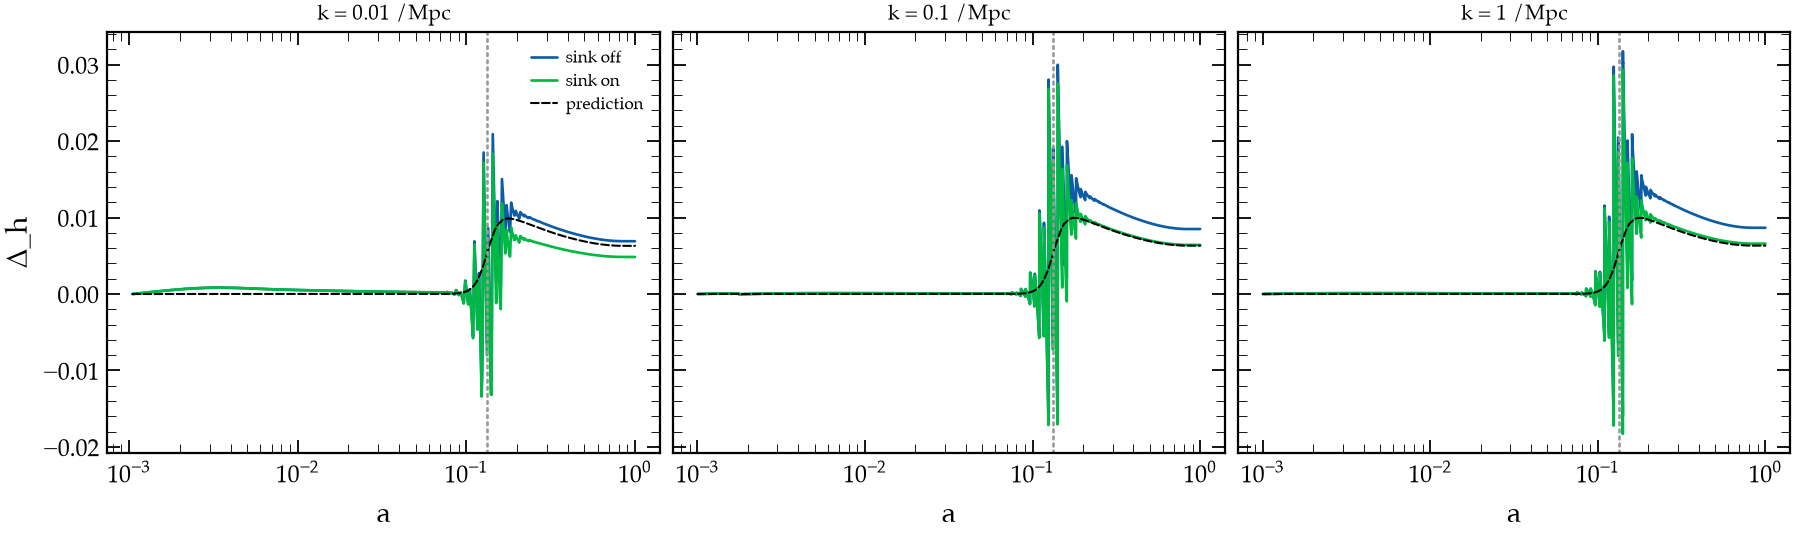

In [3]:
drift = {}
for sink in ('no', 'yes'):
    p = accdm_params(F_ACC, 1e16, eta=ETA, ncdm_N_momentum_bins='15, 51', accdm_q_log_share=1,
                     acc_de_sink=sink, **OUTPUT)
    pk, bg = run(p)
    drift[sink] = {k: trace_drift(x, bg, k, ETA) for k, x in zip(K_OUT, pk)}

print('{:>6} {:>13} {:>13} {:>13} {:>10} {:>10}'.format(
    'k', 'off: D_h(1)', 'on: D_h(1)', 'on: pred(1)', 'meas/pred', 'floor'))
for k in K_OUT:
    off, on = drift['no'][k], drift['yes'][k]
    m, p = on['Delta_h'][-1], on['pred'][-1]
    print('{:>6g} {:>+13.3e} {:>+13.3e} {:>+13.3e} {:>10.3f} {:>10.2e}'.format(
        k, off['Delta_h'][-1], m, p, m/p, floor(on)))

fig, axes = plt.subplots(1, len(K_OUT), figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, k in zip(axes, K_OUT):
    ax.semilogx(drift['no'][k]['a'], drift['no'][k]['Delta_h'], label='sink off')
    ax.semilogx(drift['yes'][k]['a'], drift['yes'][k]['Delta_h'], label='sink on')
    ax.semilogx(drift['yes'][k]['a'], drift['yes'][k]['pred'], 'k--', lw=1, label='prediction')
    ax.axvline(A_T, color='0.6', ls=':')
    ax.set_title('k = {:g} /Mpc'.format(k), fontsize=10)
    ax.set_xlabel('a')
axes[0].set_ylabel('Δ_h')
axes[0].legend(fontsize=8)
plt.show()

## Result

In [4]:
worst_on = max(abs(drift['yes'][k]['Delta_h'][-1]) for k in K_OUT)
worst_floor = max(floor(drift['yes'][k]) for k in K_OUT)
change = max(abs(drift['yes'][k]['Delta_h'][-1]/drift['no'][k]['Delta_h'][-1] - 1) for k in K_OUT)
print('ΛCDM null floor                 {:.1e}'.format(NULL))
print('largest |Delta_h(1)|, sink on   {:.1e}  (own pre-injection floor {:.1e})'.format(worst_on, worst_floor))
print('largest change from the sink    {:.0%}'.format(change))

ΛCDM null floor                 8.3e-04
largest |Delta_h(1)|, sink on   6.6e-03  (own pre-injection floor 8.3e-04)
largest change from the sink    30%
